In [2]:
from fastai.vision.all import *

In [3]:
path = untar_data(URLs.PETS)

In [4]:
files = get_image_files(path/'images')

In [5]:
print(files)

[Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/Egyptian_Mau_167.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/pug_52.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/basset_hound_112.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/Siamese_193.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/shiba_inu_122.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/Siamese_53.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/Birman_167.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/leonberger_6.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/Siamese_47.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/shiba_inu_136.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/saint_bernard_139.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/Birman_173.jpg'), Path('/Users/Yashwanth.B/.f

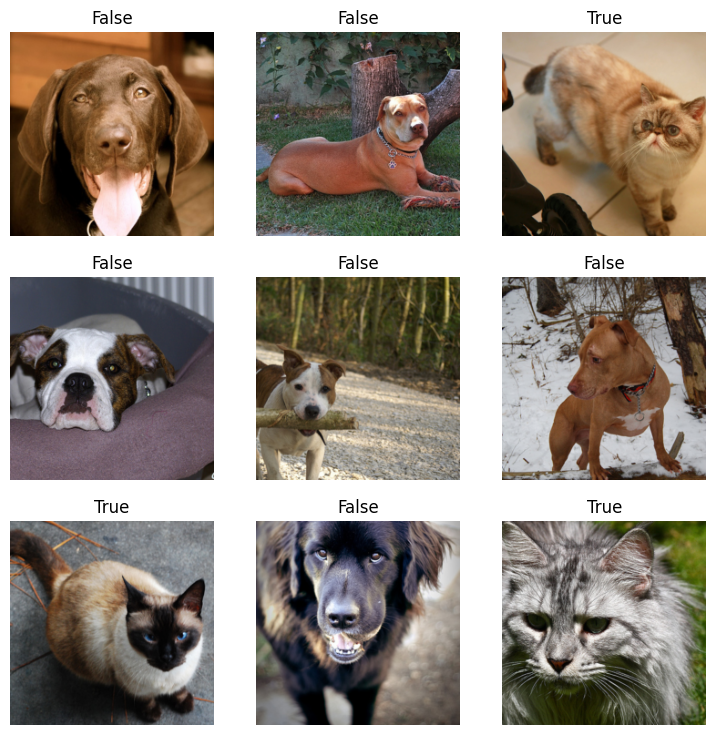

In [7]:
def get_label(f): return f[0].isupper()
dls = ImageDataLoaders.from_name_func(path, files, get_label, item_tfms=Resize(224))
dls.show_batch()

<div></div>

epoch,train_loss,valid_loss,accuracy,error_rate,time
0,0.229060,0.027539,0.991881,0.008119,00:37


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,0.065529,0.012768,0.995264,0.004736,00:46


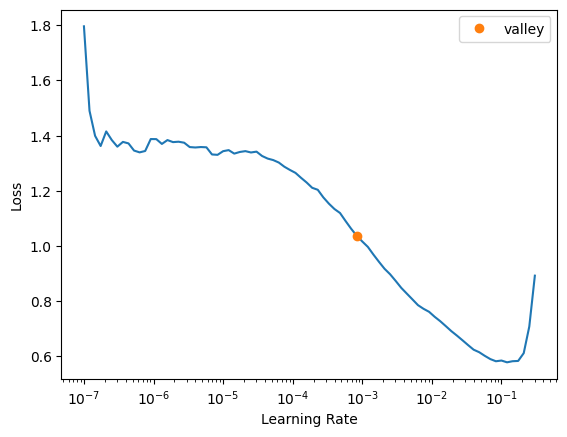

In [29]:
learner = vision_learner(dls, resnet18, metrics=[accuracy, error_rate])
plot = learner.lr_find(suggest_funcs=(valley))
learner.fine_tune(1, plot.valley)

In [31]:
learner.predict(files[1])

('False', tensor(0), tensor([0.9760, 0.0240]))

In [32]:
learner.summary()

<div></div>

Sequential (Input shape: 64 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 64 x 112 x 112 
Conv2d                                    9408       True      
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 64 x 56 x 56   
MaxPool2d                                                      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                      

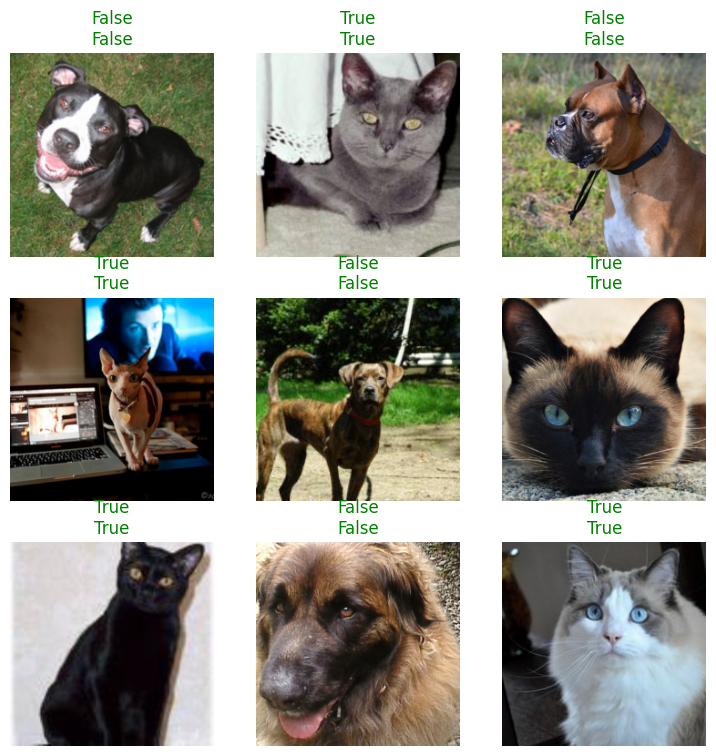

In [33]:
learner.show_results()